In [100]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pickle
import os
from PIL import Image
from matplotlib.pyplot import GridSpec
from sklearn.preprocessing import LabelEncoder

In [101]:
DATA_DIR = "../../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [ ]:
train_df = pd.read_csv(f"{DATASET_DIR}/train1.csv")
val_df = pd.read_csv(f"{DATASET_DIR}/val1.csv")
test_df = pd.read_csv(f"{DATASET_DIR}/test1.csv")

In [ ]:
# shuffle val and test
val_df = val_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [165]:
train_df["Label"].value_counts()

Label
Malicious    50000
Benign       10000
Name: count, dtype: int64

In [166]:
# verify the images in train are not in val or test
train_images = set(train_df["Image"])
val_images = set(val_df["Image"])
test_images = set(test_df["Image"])

assert len(train_images.intersection(val_images)) == 0
assert len(train_images.intersection(test_images)) == 0

# verify the images in val are not in test
assert len(val_images.intersection(test_images)) == 0

In [167]:
class CustomDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, epsilon=0):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.epsilon = epsilon
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
        
        # Load and binarize image
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)  # Shape: [1, H, W], values 0 or 1
        
        # Generate perturbation mask
        H, W = img.shape[1], img.shape[2]
        perturb_mask = torch.zeros((H, W), dtype=torch.bool)
        if self.epsilon > 0:
            # Randomly select `epsilon` pixels to perturb
            flat_indices = torch.randperm(H * W)[:self.epsilon]
            perturb_mask.view(-1)[flat_indices] = True
        
        # Create interval bounds (lower and upper channels)
        lower = img.squeeze(0).clone()  # Shape: [H, W]
        upper = img.squeeze(0).clone()
        lower[perturb_mask] = 0  # Perturbed pixels: lower bound = 0
        upper[perturb_mask] = 1  # Perturbed pixels: upper bound = 1
        
        # Stack into 2 channels (lower + upper bounds)
        interval_img = torch.stack([lower, upper], dim=0)  # Shape: [2, H, W]
        
        return interval_img, label

In [168]:
LE = LabelEncoder()
LE.fit(train_df["Label"].unique())

LE.classes_

# swap classes in the label encoder
swapped_classes = LE.classes_.copy()
swapped_classes[0], swapped_classes[1] = swapped_classes[1], swapped_classes[0]

LE.classes_ = swapped_classes

train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

val_df_encoded = val_df.copy()
val_df_encoded["Label"] = LE.transform(val_df_encoded["Label"])

train_df_encoded.head()

,Image,Label
0,image_566053.png,1
1,image_1260895.png,1
2,image_2675864.png,1
3,image_5798756.png,1
4,image_5737705.png,1


In [169]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

train_dataset = CustomDataset(train_df_encoded, f"{DATASET_DIR}/images", transform=transform, epsilon=3)
val_dataset = CustomDataset(val_df_encoded, f"{DATASET_DIR}/images", transform=transform)

In [170]:
from torch.utils.data import WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight

labels = train_df_encoded["Label"].values
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(labels), y=labels)
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

pos_weight = torch.tensor(class_weights[1] / class_weights[0])

In [171]:
BATCH_SIZE = 40
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [172]:
class BinaryAbstractionCNN(nn.Module):
    def __init__(self, img_size=32, num_classes=2):
        super().__init__()
        # Input: 2 channels (lower/upper bounds for binary pixels)
        self.features = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, padding=1),  # 2 input channels
            nn.ReLU(),
            nn.MaxPool2d(2),  # e.g., 28x28 → 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14x14 → 7x7
        )
        # Calculate flattened size based on img_size
        self.flattened_size = 64 * (img_size // 4) * (img_size // 4)
        self.classifier = nn.Sequential(
            nn.Linear(self.flattened_size, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [173]:
dummy = torch.zeros(40, 2, 32, 32, dtype=torch.float32)
model = BinaryAbstractionCNN()
model(dummy).shape

torch.Size([40, 2])

In [174]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion_cross_entropy = nn.CrossEntropyLoss
criterion_logits = nn.BCEWithLogitsLoss

In [175]:
# calculate metrics for binary classification
# accuracy, precision, recall, f1 score
# use sklearn to calculate these metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="micro")
    recall = recall_score(y_true, y_pred, average="micro")
    f1 = f1_score(y_true, y_pred, average="micro")
    
    return accuracy, precision, recall, f1

def calculate_class_metrics(y_true, y_pred):
    return {
        "overall_accuracy": accuracy_score(y_true, y_pred),
        "benign_f1": f1_score(y_true, y_pred, pos_label=1),
        "benign_precision": precision_score(y_true, y_pred, pos_label=1),
        "benign_recall": recall_score(y_true, y_pred, pos_label=1),
        "malicious_f1": f1_score(y_true, y_pred, pos_label=0),
        "malicious_precision": precision_score(y_true, y_pred, pos_label=0),
        "malicious_recall": recall_score(y_true, y_pred, pos_label=0),
    }

from sklearn.metrics import precision_recall_curve

def find_optimal_threshold(y_true, y_probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    optimal_idx = np.argmax(f1_scores)
    return thresholds[optimal_idx]

In [ ]:
def train_model_reduceonplateau(model_class, loss_class, train_dataloader, val_dataloader, num_epochs=50, lr=1e-3, early_stop=10, device="cuda", weights=None, pos_weights=None, model_savepath=None, weight_decay=0.0, debug=False):
    
    if loss_class == nn.BCEWithLogitsLoss:
        criterion = loss_class(pos_weight=pos_weights) if pos_weights is not None else loss_class()
        model = model_class(num_classes=1)

    elif loss_class == nn.CrossEntropyLoss:
        criterion = loss_class(weight=weights) if weights is not None else loss_class()
        model = model_class(num_classes=2)
    else:
        criterion = loss_class()
        model = model_class(num_classes=2)

    model = model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay, betas=(0.9, 0.999))
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.1)

    best_val_f1 = 0  # Track best overall weighted F1 score
    best_epoch = 0
    best_model = None
    early_stop_counter = 0

    best_threshold = 0.5  # For BCEWithLogitsLoss

    history = {
        "overall_accuracy": {"train": [], "val": []},
        "overall_precision": {"train": [], "val": []},
        "overall_recall": {"train": [], "val": []},
        "overall_f1": {"train": [], "val": []},
        "train_loss": [], "val_loss": [],
        "benign_metrics": {
            "train": {"precision": [], "recall": [], "f1": []},
            "val": {"precision": [], "recall": [], "f1": []}
        },
        "malicious_metrics": {
            "train": {"precision": [], "recall": [], "f1": []},
            "val": {"precision": [], "recall": [], "f1": []}
        }
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Training phase
        model.train()
        train_loss = 0.0
        train_preds, train_true, train_probs = [], [], []

        for images, labels in tqdm(train_dataloader, desc="Training Batches"):
            labels = labels.float().to(device) if loss_class == nn.BCEWithLogitsLoss else labels.long().to(device)
            images = images.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            
            if loss_class == nn.BCEWithLogitsLoss:
                outputs = outputs.squeeze(-1)
            
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            with torch.no_grad():
                if loss_class == nn.CrossEntropyLoss:
                    probs = torch.softmax(outputs, dim=1).cpu().numpy()
                    preds = torch.argmax(outputs, dim=1).cpu().numpy()
                else:
                    probs = torch.sigmoid(outputs).cpu().numpy()
                    preds = (probs > best_threshold).astype(int)

            train_preds.extend(preds)
            train_true.extend(labels.cpu().numpy())
            train_probs.extend(probs)

        train_loss /= len(train_dataloader)
        train_metrics = calculate_class_metrics(train_true, train_preds)

        # Validation phase
        val_loss = 0.0
        val_preds, val_true, val_probs = [], [], []

        with torch.no_grad():
            model.eval()
            for images, labels in tqdm(val_dataloader, desc="Validation Batches"):
                labels = labels.float().to(device) if loss_class == nn.BCEWithLogitsLoss else labels.long().to(device)
                images = images.to(device)

                outputs = model(images)
                
                if loss_class == nn.BCEWithLogitsLoss:
                    outputs = outputs.squeeze(-1)
                
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                if loss_class == nn.CrossEntropyLoss:
                    probs = torch.softmax(outputs, dim=1).cpu().numpy()
                    preds = torch.argmax(outputs, dim=1).cpu().numpy()
                else:
                    probs = torch.sigmoid(outputs).cpu().numpy()
                    preds = (probs > best_threshold).astype(int)

                val_preds.extend(preds)
                val_true.extend(labels.cpu().numpy())
                val_probs.extend(probs)

        val_loss /= len(val_dataloader)

        # Calculate optimal threshold (only for BCEWithLogitsLoss)
        if loss_class == nn.BCEWithLogitsLoss:
            optimal_threshold = find_optimal_threshold(val_true, val_probs)
            val_preds = (np.array(val_probs) > optimal_threshold).astype(int)
            if f1_score(val_true, val_preds, average="weighted") > best_val_f1:
                best_val_f1 = f1_score(val_true, val_preds, average="weighted")
                best_threshold = optimal_threshold

        val_metrics = calculate_class_metrics(val_true, val_preds)

        # Compute overall weighted metrics
        overall_f1_train = f1_score(train_true, train_preds, average="weighted")
        overall_f1_val = f1_score(val_true, val_preds, average="weighted")
        overall_precision_train = precision_score(train_true, train_preds, average="weighted")
        overall_precision_val = precision_score(val_true, val_preds, average="weighted")
        overall_recall_train = recall_score(train_true, train_preds, average="weighted")
        overall_recall_val = recall_score(val_true, val_preds, average="weighted")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["overall_accuracy"]["train"].append(train_metrics["overall_accuracy"])
        history["overall_accuracy"]["val"].append(val_metrics["overall_accuracy"])
        history["overall_f1"]["train"].append(overall_f1_train)
        history["overall_f1"]["val"].append(overall_f1_val)
        history["overall_precision"]["train"].append(overall_precision_train)
        history["overall_precision"]["val"].append(overall_precision_val)
        history["overall_recall"]["train"].append(overall_recall_train)
        history["overall_recall"]["val"].append(overall_recall_val)

        for metric in ["precision", "recall", "f1"]:
            history["benign_metrics"]["train"][metric].append(train_metrics[f"benign_{metric}"])
            history["benign_metrics"]["val"][metric].append(val_metrics[f"benign_{metric}"])
            history["malicious_metrics"]["train"][metric].append(train_metrics[f"malicious_{metric}"])
            history["malicious_metrics"]["val"][metric].append(val_metrics[f"malicious_{metric}"])

        print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
        print(f"Overall Accuracy - Train: {train_metrics['overall_accuracy']:.4f}, Val: {val_metrics['overall_accuracy']:.4f}")
        print(f"Overall F1 - Train: {overall_f1_train:.4f}, Val: {overall_f1_val:.4f}")
        print(f"Overall Precision - Train: {overall_precision_train:.4f}, Val: {overall_precision_val:.4f}")
        print(f"Overall Recall - Train: {overall_recall_train:.4f}, Val: {overall_recall_val:.4f}")

        # Early stopping with model saving based on weighted F1
        if overall_f1_val > best_val_f1:
            best_val_f1 = overall_f1_val
            best_epoch = epoch
            best_model = model.state_dict()
            torch.save(model.state_dict(), model_savepath) if model_savepath else None
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= early_stop:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        scheduler.step(val_loss)

    print(f"\nBest model was from epoch {best_epoch+1} with validation weighted F1 {best_val_f1:.4f}")
    return best_model, history, best_threshold if loss_class == nn.BCEWithLogitsLoss else best_model, history


In [177]:
def plot_metrics(history):
    gs = GridSpec(2, 2)
    fig = plt.figure(figsize=(12, 12))

    ax = [
        [fig.add_subplot(gs[0, :])],
        [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
    ]



    # Loss
    ax[0][0].plot(history["train_loss"], label="Train Loss")
    ax[0][0].plot(history["val_loss"], label="Val Loss")
    ax[0][0].set_title("Loss")
    # ax[0][0].set_ylim(
    ax[0][0].legend()


    # Accuracy
    ax[1][0].plot(history["overall_accuracy"]["train"], label="Train Accuracy")
    ax[1][0].plot(history["overall_accuracy"]["val"], label="Val Accuracy")
    ax[1][0].set_title("Accuracy")
    # ax[1][0].set_ylim(ymin, ymax)
    ax[1][0].legend()


    # Precision, Recall, F1
    for i, metric in enumerate(["precision", "recall", "f1"]):
        ax[1][1].plot(history["benign_metrics"]["train"][metric], label=f"Train Benign {metric.capitalize()}")
        ax[1][1].plot(history["benign_metrics"]["val"][metric], label=f"Val Benign {metric.capitalize()}")
        ax[1][1].plot(history["malicious_metrics"]["train"][metric], label=f"Train Malicious {metric.capitalize()}")
        ax[1][1].plot(history["malicious_metrics"]["val"][metric], label=f"Val Malicious {metric.capitalize()}")
        ax[1][1].set_title("Metrics")
    # ax[1][1].set_ylim(ymin, ymax)
    ax[1][1].legend()


    plt.tight_layout()
    plt.show()


In [ ]:
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(train_df_encoded["Label"]), y=train_df_encoded["Label"])
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
pos_weights = pos_weight.to(device)

class_weights, pos_weights

(tensor([0.6000, 3.0000], device='cuda:0'),
 tensor(5., device='cuda:0', dtype=torch.float64))

In [179]:
model_savepath = f"../../models/checkpoints/cnn/"
os.makedirs(model_savepath, exist_ok=True)


Epoch 1/50
--------------------------------------------------


Validation Batches: 100%|██████████| 1500/1500 [01:48<00:00, 13.81it/s]



Loss - Train: 0.1557, Val: 0.4284
Accuracy - Train: 0.8778, Val: 0.8442

Epoch 2/50
--------------------------------------------------


Validation Batches: 100%|██████████| 1500/1500 [03:27<00:00,  7.23it/s]



Loss - Train: 0.1255, Val: 0.5251
Accuracy - Train: 0.9030, Val: 0.8377

Epoch 3/50
--------------------------------------------------


...


Loss - Train: 0.0874, Val: 0.3860
Accuracy - Train: 0.9263, Val: 0.8665

Epoch 20/50
--------------------------------------------------


Validation Batches: 100%|██████████| 1500/1500 [01:13<00:00, 20.39it/s]



Loss - Train: 0.0864, Val: 0.3810
Accuracy - Train: 0.9272, Val: 0.8674

Epoch 21/50
--------------------------------------------------


Validation Batches: 100%|██████████| 1500/1500 [01:26<00:00, 17.28it/s]



Loss - Train: 0.0855, Val: 0.3809
Accuracy - Train: 0.9276, Val: 0.8676

Early stopping at epoch 21

Best model was from epoch 11 with validation loss 0.3382


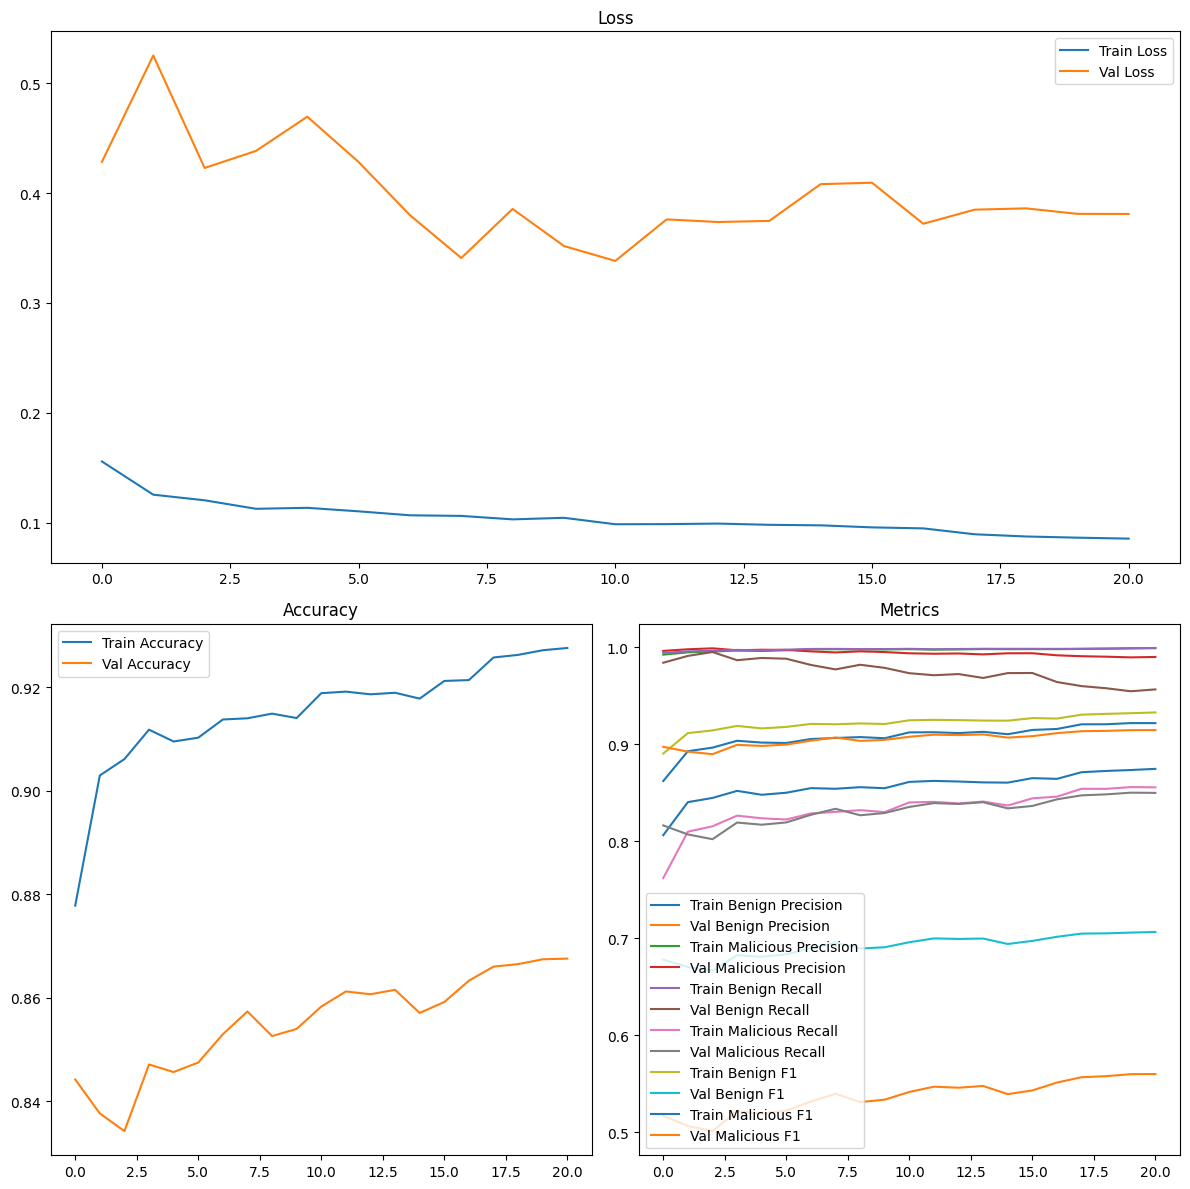

In [180]:
_, history_ce = train_model_reduceonplateau(BinaryAbstractionCNN, criterion_cross_entropy, train_data_loader, val_data_loader, num_epochs=50, lr=1e-3, early_stop=10, device=device, weights=class_weights, model_savepath=f"{model_savepath}abstract_cnn.pt", debug=False)

plot_metrics(history_ce)

In [148]:
test_data_encoded = test_df.copy()
test_data_encoded["Label"] = LE.transform(test_data_encoded["Label"])

test_dataset = CustomDataset(test_data_encoded, f"{DATASET_DIR}/images", transform=transform)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [160]:
def test_model(model, test_dataloader, loss_class, device="cuda", return_probs=False, threshold=0.5, pos_weight=None, class_weights=None):
    model = model.to(device)
    
    model.eval()
    test_loss = 0.0
    all_preds = []
    all_true = []
    all_probs = []
    
    # Initialize criterion based on loss class
    if loss_class == nn.BCEWithLogitsLoss:
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    elif loss_class == nn.CrossEntropyLoss:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        raise ValueError("Unsupported loss class")

    with torch.no_grad():
        for images, labels in tqdm(test_dataloader, desc="Testing Batches"):
            # Move data to device and format labels
            images = images.to(device)
            
            if loss_class == nn.CrossEntropyLoss:
                labels = labels.long().to(device)  # CrossEntropy needs long labels
            else:
                labels = labels.float().to(device)  # BCE needs float labels

            outputs = model(images)

            if loss_class == nn.BCEWithLogitsLoss:
                outputs = outputs.squeeze(-1)

            loss = criterion(outputs, labels)
            test_loss += loss.item()

            # Calculate probabilities and predictions
            if loss_class == nn.CrossEntropyLoss:
                probs = torch.softmax(outputs, dim=1)
                preds = torch.argmax(probs, dim=1)
            else:
                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).int().squeeze()

            # Store results
            all_true.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    test_loss /= len(test_dataloader)
    metrics = calculate_class_metrics(all_true, all_preds)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {metrics['overall_accuracy']:.4f}")
    print(f"Test Benign - Precision: {metrics['benign_precision']:.4f}, Recall: {metrics['benign_recall']:.4f}, F1: {metrics['benign_f1']:.4f}")
    print(f"Test Malicious - Precision: {metrics['malicious_precision']:.4f}, Recall: {metrics['malicious_recall']:.4f}, F1: {metrics['malicious_f1']:.4f}")


    if return_probs:
        return {
            'loss': test_loss,
            'metrics': metrics,
            'true_labels': np.array(all_true),
            'pred_labels': np.array(all_preds),
            'probabilities': np.array(all_probs)
        }
    return {
        'loss': test_loss,
        'metrics': metrics,
        'true_labels': np.array(all_true),
        'pred_labels': np.array(all_preds)
    }

def test_metrics(true, preds):
    accuracy, precision, recall, f1 = calculate_metrics(true, preds)
    
    # confusion matrix
    cm = confusion_matrix(true, preds)

    # plot confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

    plt.title("Confusion Matrix")

    plt.colorbar()

    # 1 is benign, 0 is malicious in predictions and labels

    
    plt.xticks([0, 1], LE.classes_)
    plt.yticks([0, 1], LE.classes_)
    plt.grid(False)


    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='red')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")



    plt.show()

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return accuracy, precision, recall, f1

In [ ]:
# sample 12000 data points from test data with equal distribution of benign and malicious samples
test_data_sample = test_data_encoded.groupby("Label").sample(6000, random_state=42)

# shuffle the data
test_data_sample = test_data_sample.sample(frac=1, random_state=42).reset_index(drop=True) 

test_dataset_sample = CustomDataset(test_data_sample, f"{DATASET_DIR}/images", transform=transform)
test_data_loader_sample = DataLoader(test_dataset_sample, batch_size=BATCH_SIZE, shuffle=False)

In [162]:
model = BinaryAbstractionCNN(num_classes=1).to(device)

model_info = torch.load(f"{model_savepath}abstract_cnn_bce.pt", weights_only=False)

model.load_state_dict(model_info["model_state_dict"])

<All keys matched successfully>

In [163]:
test_stats = test_model(model, test_data_loader_sample, criterion_logits, device=device, return_probs=True, threshold=threshold, pos_weight=pos_weights)

Testing Batches: 100%|██████████| 300/300 [00:10<00:00, 29.95it/s]


Test Loss: 0.3053
Test Accuracy: 0.9547
Test Benign - Precision: 0.9318, Recall: 0.9812, F1: 0.9558
Test Malicious - Precision: 0.9801, Recall: 0.9282, F1: 0.9534


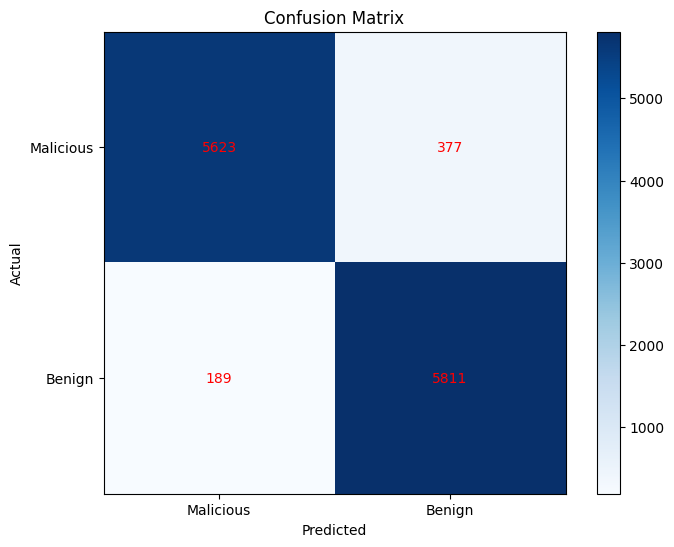

Accuracy: 0.9528
Precision: 0.9528
Recall: 0.9528
F1 Score: 0.9528


(0.9528333333333333,
 np.float64(0.9528333333333333),
 np.float64(0.9528333333333333),
 np.float64(0.9528333333333333))

In [155]:
test_metrics(test_stats["true_labels"], test_stats["pred_labels"])